<a href="https://colab.research.google.com/github/24Sinchana/project/blob/main/ML%20PROJECTS/CIFAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#object recognition in images
!pip install kaggle #kaggle library

In [3]:
# configuring the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
#dataset API
!kaggle competitions download -c cifar-10

100% 714M/715M [00:04<00:00, 148MB/s]
100% 715M/715M [00:04<00:00, 164MB/s]


In [5]:
!ls

cifar-10.zip  kaggle.json  sample_data


In [6]:
#extracting the compressed dataset
from zipfile import ZipFile
dataset = '/content/cifar-10.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [7]:
!ls

cifar-10.zip  kaggle.json  sample_data	sampleSubmission.csv  test.7z  train.7z  trainLabels.csv


In [8]:
!pip install py7zr #install library
#7z file cant be extracted using ZipFile

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.2/96.2 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.6/50.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.3/141.3 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.7/413.7 kB 13.6 MB/s eta 0:00:00


In [9]:
import py7zr
archive = py7zr.SevenZipFile('/content/train.7z',mode='r')
archive.extractall()
#archive.extractall(path ='')
archive.close()

In [10]:
!ls

cifar-10.zip  sample_data	    test.7z  train.7z
kaggle.json   sampleSubmission.csv  train    trainLabels.csv


In [11]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.pyplot as mpimg
from sklearn.model_selection import train_test_split

In [12]:
filenames = os.listdir('/content/train')
type(filenames)
print(len(filenames))

50000


In [13]:
print(filenames[0:5])
print(filenames[-5:])

['7251.png', '47955.png', '31267.png', '35553.png', '41682.png']
['24525.png', '35394.png', '38764.png', '45170.png', '44649.png']


labels proccessing

In [14]:
label_df = pd.read_csv('/content/trainLabels.csv')

In [15]:
label_df.shape

(50000, 2)

In [16]:
label_df.head()

,id,label
0,1,frog
1,2,truck
2,3,truck
3,4,deer
4,5,automobile


In [17]:
label_df[label_df['id']== 45888]

,id,label
45887,45888,dog


In [18]:
label_df.head(10)

,id,label
0,1,frog
1,2,truck
2,3,truck
3,4,deer
4,5,automobile
5,6,automobile
6,7,bird
7,8,horse
8,9,ship
9,10,cat


In [19]:
label_df.tail(10)

,id,label
49990,49991,deer
49991,49992,bird
49992,49993,airplane
49993,49994,automobile
49994,49995,airplane
49995,49996,bird
49996,49997,frog
49997,49998,truck
49998,49999,automobile
49999,50000,automobile


In [20]:
#numerical encoding(label encoding /manual converting/one not encoding)
label_df['label'].value_counts()

,count
label,
frog,5000
truck,5000
deer,5000
automobile,5000
bird,5000
horse,5000
ship,5000
cat,5000
dog,5000


In [21]:
#id is not in order so we process it to read images in order
label_dictionary = {'airplane':0, 'automobile':1,  'bird':2 , 'cat':3 , 'deer':4, 'dog':5,'frog': 6, 'horse':7 , 'ship':8, 'truck':9}
labels = [label_dictionary[i] for i in label_df['label']] #create list with for loop

print(labels[0:5])
print(labels[-5:])

[6, 9, 9, 4, 1]
[2, 6, 9, 1, 1]


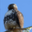

In [22]:
#display sample image
import cv2
from google.colab.patches import cv2_imshow  #we cant use imshow
img = cv2.imread('/content/train/41513.png')
cv2_imshow(img)

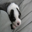

In [23]:
import cv2
from google.colab.patches import cv2_imshow  #we cant use imshow
img = cv2.imread('/content/train/45888.png')
cv2_imshow(img)

In [24]:
#read images in order
#create list having vaues from 0 to 50000
label_df.head()

,id,label
0,1,frog
1,2,truck
2,3,truck
3,4,deer
4,5,automobile


In [25]:
id_list = list(label_df['id'])
print(id_list[0:5])
print(id_list[-5:])

[1, 2, 3, 4, 5]
[49996, 49997, 49998, 49999, 50000]



image processing

In [26]:
#convert images to numpy arrays
train_data_folder = '/content/train/'

#covert to 50000 numpy array
data = []

for id in id_list:

  image = Image.open(train_data_folder + str(id) + '.png') #convert id to string str(id)
  #pillow object
  img = np.array(image)
  data.append(img)

In [27]:
type(data[0])

numpy.ndarray

In [28]:
print(len(data))

50000


In [29]:
data[0].shape #( =image =red green blue -3)

(32, 32, 3)

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]], dtype=uint8)
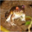

In [30]:
data[0]
#when we convert the images t0 numpy array all the values ranges between 0 and 250

In [31]:
#Convert label list and images list to numpy array
X=np.array(data)
Y=np.array(labels)
print(type(X))
print(X.shape)
print(Y.shape)

<class 'numpy.ndarray'>
(50000, 32, 32, 3)
(50000,)


In [32]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=2)

In [33]:
print(X.shape,X_train.shape,X_test.shape)

(50000, 32, 32, 3) (40000, 32, 32, 3) (10000, 32, 32, 3)


In [34]:
#scale down the data or normalization
X_train_scaled=X_train/255
X_test_scaled=X_test/255
X_train_scaled

array([[[[0.81960784, 0.82352941, 0.79607843],
         [0.83529412, 0.83921569, 0.81960784],
         [0.85490196, 0.85882353, 0.84313725],
         ...,
         [0.49803922, 0.29019608, 0.15294118],
         [0.47843137, 0.26666667, 0.1372549 ],
         [0.45490196, 0.24705882, 0.1254902 ]],

        [[0.82352941, 0.82352941, 0.79215686],
         [0.83529412, 0.83921569, 0.81176471],
         [0.85490196, 0.8627451 , 0.83921569],
         ...,
         [0.48627451, 0.2745098 , 0.1372549 ],
         [0.4745098 , 0.2627451 , 0.12941176],
         [0.48235294, 0.27058824, 0.14117647]],

        [[0.80784314, 0.80392157, 0.76470588],
         [0.81960784, 0.81960784, 0.79215686],
         [0.83529412, 0.84313725, 0.81960784],
         ...,
         [0.48627451, 0.2745098 , 0.14509804],
         [0.51372549, 0.30196078, 0.16470588],
         [0.51372549, 0.30588235, 0.16078431]],

        ...,

        [[0.49803922, 0.42352941, 0.38039216],
         [0.54117647, 0.47843137, 0.43137255]

In [35]:
#building neural network
!pip install tensorflow # Ensure TensorFlow is installed
import tensorflow as tf

num_of_classes = 10

#setting up the layers of the neural network
model = tf.keras.Sequential([  # Use tf.keras.Sequential instead of tf_keras.Sequential

    tf.keras.layers.Flatten(input_shape=(32,32,3)), # Use tf.keras.layers.Flatten instead of tf_keras.flatten
    tf.keras.layers.Dense(64,activation='relu'), #64-number of neural layers
    tf.keras.layers.Dense(num_of_classes,activation ='softmax') #output layers

])

model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 3072)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         196,672 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 197,322 (770.79 KB)

 Trainable params: 197,322 (770.79 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
#compile
model.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['acc'])

In [37]:
#training the neural network
model.fit(X_train_scaled,Y_train,validation_split=0.1,epochs=10)
#epoch gives training accuracy and validation accuracy

Epoch 1/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - acc: 0.2542 - loss: 2.0432 - val_acc: 0.3447 - val_loss: 1.7980
Epoch 2/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.3444 - loss: 1.8373 - val_acc: 0.3313 - val_loss: 1.8102
Epoch 3/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.3632 - loss: 1.7717 - val_acc: 0.3753 - val_loss: 1.7427
Epoch 4/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc: 0.3835 - loss: 1.7333 - val_acc: 0.3947 - val_loss: 1.6988
Epoch 5/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - acc: 0.3939 - loss: 1.6955 - val_acc: 0.3837 - val_loss: 1.7059
Epoch 6/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - acc: 0.3985 - loss: 1.6903 - val_acc: 0.3697 - val_loss: 1.7279
Epoch 7/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - acc: 0.4022 - loss: 1.6776 - val_acc: 0.3975 - val_loss: 1.6624
Epoch 8/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - acc: 0.3996 - loss: 1.6704 - val_acc: 0.4070 - val_loss: 1.6487
Epoch 9/10
1125/1125 ━━━━━━━━━━━━━━━━━━

In [38]:
#when loss function decreases acuuracy increases
#transfer learning-pretrained model

In [39]:
#training pretrained model called ResNet50
from tensorflow.keras import Sequential,models,layers
from tensorflow.keras.layers import Dense,Dropout,Flatten
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.models import load_model
from tensorflow.keras import Model
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras import optimizers

In [40]:
convulation_base = ResNet50(weights='imagenet', include_top=False, input_shape=(256,256,3))

#resnet50 is trained on the data imagenet and it derives some weights
#imagenet contains 1000 classes
#include_top=False -it imports resnet layers and drops final layer(output layer) we add our own custom output layer with 10 neurons
#these layer can capture the info in the images better
#resnet takes the images of the size 256
convulation_base.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 256, 256, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 262, 262, 3)    │              0 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 128, 128, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 128, 128, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 128, 128, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 130, 130, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 64, 64, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 64, 64, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 64, 64, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 64, 64, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 64, 64, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 64, 64, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 64, 64, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 64, 64, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 64, 64, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)             

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [41]:
#it doesnt have output layer so we add our own layer
num_of_classes=10
model = models.Sequential()
model.add(layers.UpSampling2D((2,2))) #height and width multiply by 2(scaling up the images) 64*64
model.add(layers.UpSampling2D((2,2))) #128*128
model.add(layers.UpSampling2D((2,2))) #256*256
model.add(convulation_base) #all the layers
model.add(layers.Flatten()) #flatten converts matrix into vectors(single column)
model.add(layers.BatchNormalization()) #ensures all the values are of same range
model.add(layers.Dense(128,activation='relu')) #128 neurons
model.add(layers.Dropout(0.5)) #turn off few neurons so that our model do not overfit
model.add(layers.BatchNormalization())
model.add(layers.Dense(64,activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.BatchNormalization())
model.add(layers.Dense(num_of_classes,activation='softmax'))
#3 layers -input/hidden/output

In [42]:
model.compile(optimizer=optimizers.RMSprop(learning_rate=2e-5), loss='sparse_categorical_crossentropy', metrics=['acc'])

In [43]:
history = model.fit(X_train_scaled, Y_train, validation_split=0.1, epochs=10)

Epoch 1/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 443s 345ms/step - acc: 0.3332 - loss: 2.0273 - val_acc: 0.7598 - val_loss: 0.8360
Epoch 2/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 418s 347ms/step - acc: 0.6754 - loss: 1.0411 - val_acc: 0.8923 - val_loss: 0.4320
Epoch 3/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 433s 339ms/step - acc: 0.8002 - loss: 0.7416 - val_acc: 0.9185 - val_loss: 0.3280
Epoch 4/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 390s 346ms/step - acc: 0.8684 - loss: 0.5593 - val_acc: 0.9327 - val_loss: 0.2763
Epoch 5/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 434s 339ms/step - acc: 0.9031 - loss: 0.4416 - val_acc: 0.9300 - val_loss: 0.2572
Epoch 6/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 389s 346ms/step - acc: 0.9332 - loss: 0.3477 - val_acc: 0.9402 - val_loss: 0.2207
Epoch 7/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 442s 346ms/step - acc: 0.9512 - loss: 0.2791 - val_acc: 0.9405 - val_loss: 0.2176
Epoch 8/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 389s 346ms/step - acc: 0.9630 - loss: 0.2328 - val_acc: 0.9392 - val_loss: 0.2168
Epoch 9/

In [44]:
loss, accuracy = model.evaluate(X_test_scaled, Y_test)
print('Test Accuracy =', accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 112ms/step - acc: 0.9372 - loss: 0.2259
Test Accuracy = 0.9363999962806702


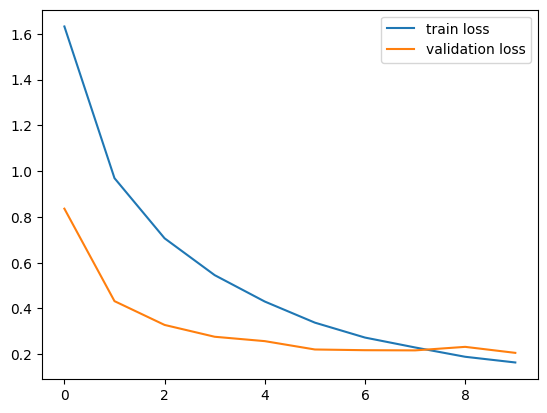

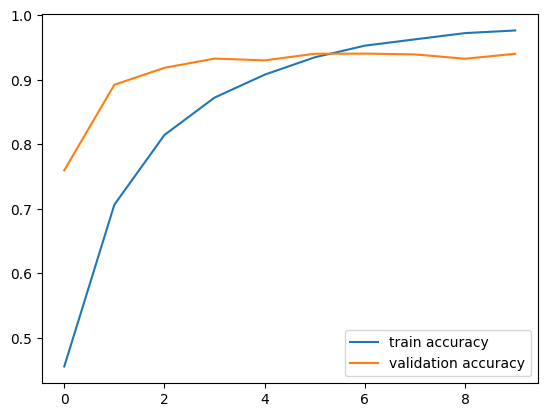

In [45]:
h = history

# plot the loss value
plt.plot(h.history['loss'], label='train loss')
plt.plot(h.history['val_loss'], label='validation loss')
plt.legend()
plt.show()

# plot the accuracy value
plt.plot(h.history['acc'], label='train accuracy')
plt.plot(h.history['val_acc'], label='validation accuracy')
plt.legend()
plt.show()

Path of the image to be predicted: /content/frog.jpg


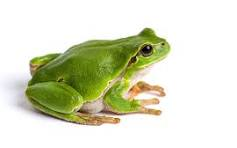

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
[[0.11205439 0.00521551 0.00741436 0.01296475 0.00548247 0.01361443
  0.81936395 0.00693742 0.01378464 0.00316808]]
6
The image represents a frog


In [50]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resize = cv2.resize(input_image, (32, 32)) # Resize to (32, 32)

input_image_scaled = input_image_resize/255

input_image_reshaped = np.reshape(input_image_scaled, [1, 32, 32, 3]) # Reshape to (1, 32, 32, 3)

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)

input_pred_label = np.argmax(input_prediction)

print(input_pred_label)


label_dictionary = {
    0: 'airplane',
    1: 'automobile',
    2: 'bird',
    3: 'cat',
    4: 'deer',
    5: 'dog',
    6: 'frog',
    7: 'horse',
    8: 'ship',
    9: 'truck'
}

for label, label_name in label_dictionary.items():
  if input_pred_label == label:
    print(f'The image represents a {label_name}')
    break  # Exit the loop once a match is found